# Data Analysis

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from class_imbalance import plot_class_imbalance
from feature_distributions import apply_class_groups
from sequence_split import split_sequences
from taxonomy_separability import (
    plot_cv_fold_class_counts,
    plot_taxonomy_class_balance,
    run_separability_probe,
    run_separability_probe_cv,
)

## Build the points table

In [2]:
df = build_and_save_points_table()

/home/bruno/radar_machine_learning_ws/results/data/points_table.parquet already covers exactly the requested sequences, skipping build


## Class imbalance

Loaded 1443816 points from /home/bruno/radar_machine_learning_ws/results/data/points_table.parquet


503759 object instances
                        count   pct
label_name                         
car                    214395  42.6
pedestrian_group       126517  25.1
pedestrian              79372  15.8
bicycle                 32881   6.5
truck                   31395   6.2
bus                      9483   1.9
other_dynamic            4558   0.9
large_vehicle            3330   0.7
motorized_two_wheeler    1617   0.3
animal                    154   0.0
train                      57   0.0


Saved plot to /home/bruno/radar_machine_learning_ws/results/class_imbalance/class_counts.png


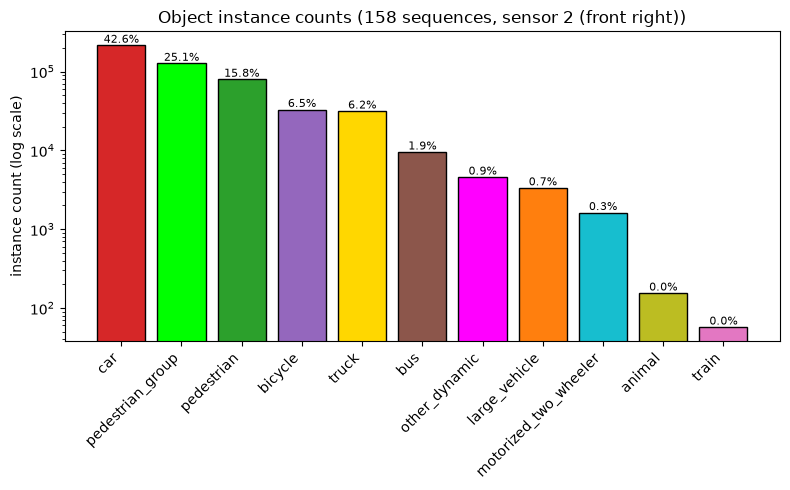

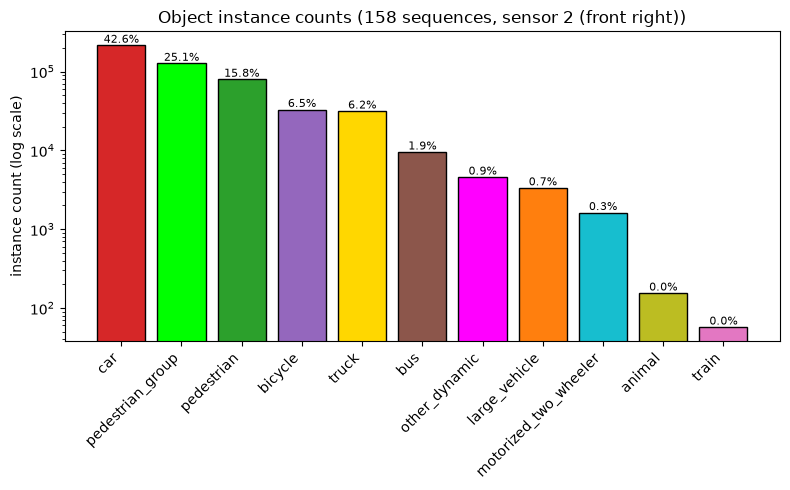

In [3]:
counts, fig = plot_class_imbalance()
fig

### Train/val/test split (sequence-grouped, final classes)

Fixed split of *sequences* into train/val/test (~70/15/15) - a sequence's points never span more
than one split, so background/weather/vehicle correlation can't leak across splits. Cached to
`results/sequence_split.json` and meant to stay fixed: val is for freely comparing candidates
(bin count, later model/architecture choices), test is checked once at the end. See
`Design_Decisions.md` decision 3's revisit note and `scripts/sequence_split.py`.

In [4]:
df_final = apply_class_groups(df)
splits = split_sequences(df_final)

/home/bruno/radar_machine_learning_ws/results/data/sequence_split.json already matches this config, reusing fixed split


       n_sequences  n_instances  pct_of_total  pct_car  pct_large_vehicle  pct_bus  pct_two_wheeler  pct_pedestrian  pct_pedestrian_group
split                                                                                                                                    
train          108       358210          71.8     42.8                7.0      1.9              7.0            15.8                  25.5
val             22        71114          14.2     43.7                6.7      2.1              6.5            15.9                  25.1
test            28        69723          14.0     43.0                7.0      1.8              7.0            16.3                  25.0


**Decision:** reduce to 6 classes, matching the official `radar_scenes` package's own
`ClassificationLabel` grouping (`radar_scenes/labels.py`). This isn't just a
convenience merge, it's the dataset authors' own recommended scheme for ML tasks:

```
car               -> car
large_vehicle      -> large_vehicle
truck              -> large_vehicle
bus                -> large_vehicle
train              -> large_vehicle
bicycle            -> two_wheeler
motorized_two_wheeler -> two_wheeler
pedestrian         -> pedestrian
pedestrian_group   -> pedestrian_group
static             -> (dropped, not trained on)
animal             -> (dropped, not trained on)
other_dynamic       -> (dropped, not trained on)
```

`animal` and `other_dynamic` are dropped rather than merged because they're low-signal catch-all classes (officially mapped to None) rather than coherent categories for a classifier.

This assumes train/truck/bus share a similar-enough radar
signature to large_vehicle that merging doesn't destroy separability. Planned
EDA (RCS/point-count distributions per class) should confirm with data rather than just
trusting the assumption. Revisit if train looks radically different. However, the train label count is too low and is essentially noise.


Merge truck, bus, and large_vehicle into a single large_vehicle class if the logistic-regression and random-forest probes, trained on the full feature vector (RCS, compensated Doppler, x_rel, y_rel, doppler_spread), shows poor held-out separability between them. Support the decision with models, rather than relying on 1D histogram overlap.

# Separability probing

/home/bruno/radar_machine_learning_ws/results/data/doppler_spread_cache.parquet covers different sequences than requested, recomputing doppler_spread


Saved doppler_spread cache to /home/bruno/radar_machine_learning_ws/results/data/doppler_spread_cache.parquet


class weights: {'truck': 1.0, 'bus': 3.3326259946949603, 'large_vehicle': 9.457282649604817}

=== logistic_regression ===
               precision    recall  f1-score   support

          bus       0.67      0.62      0.64      1943
large_vehicle       0.11      0.51      0.18       673
        truck       0.79      0.50      0.61      6267

     accuracy                           0.52      8883
    macro avg       0.52      0.54      0.48      8883
 weighted avg       0.71      0.52      0.58      8883

per-class one-vs-rest ROC-AUC:
  bus: 0.820
  large_vehicle: 0.693
  truck: 0.637
pairwise (one-vs-one) ROC-AUC:
  large_vehicle vs truck: 0.632
  large_vehicle vs bus: 0.888
  truck vs bus: 0.657
majority-class baseline (truck): 0.706 accuracy


Saved /home/bruno/radar_machine_learning_ws/results/taxonomy/taxonomy_confusion_matrix_logistic_regression.png



=== random_forest ===
               precision    recall  f1-score   support

          bus       0.53      0.62      0.57      1943
large_vehicle       0.23      0.24      0.23       673
        truck       0.80      0.76      0.78      6267

     accuracy                           0.69      8883
    macro avg       0.52      0.54      0.53      8883
 weighted avg       0.70      0.69      0.69      8883

per-class one-vs-rest ROC-AUC:
  bus: 0.816
  large_vehicle: 0.774
  truck: 0.736
majority-class baseline (truck): 0.706 accuracy
Saved /home/bruno/radar_machine_learning_ws/results/taxonomy/taxonomy_confusion_matrix_random_forest.png


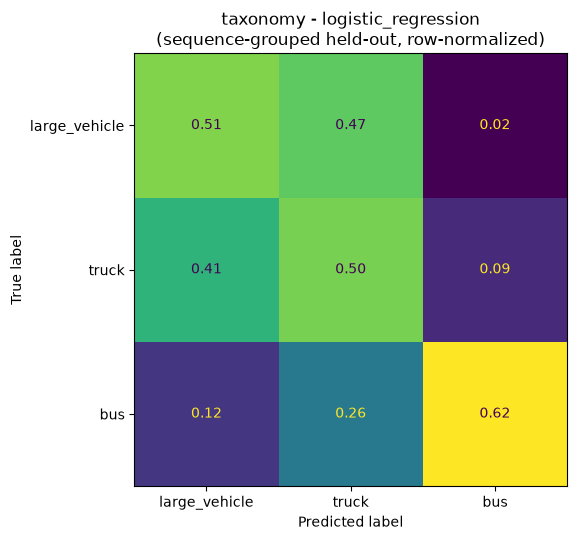

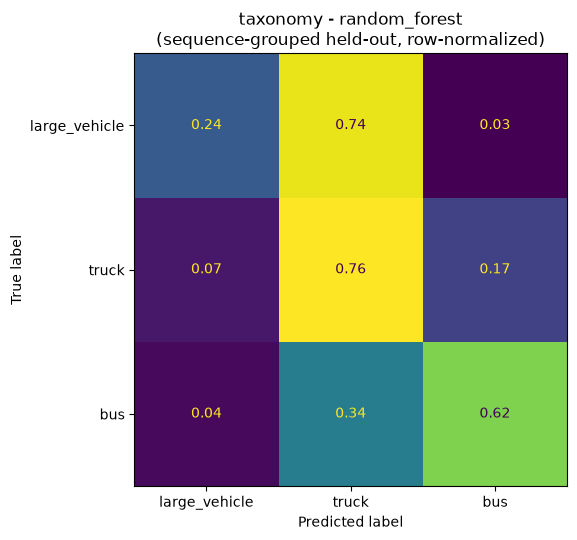

In [5]:
results = run_separability_probe(df)

large_vehicle / truck: Strong case for merging. Their pairwise AUC is the weakest of the three (0.632), and the Random-Forest confusion matrix shows large_vehicle being classified as truck 74% of the time. Both metrics point to the same conclusion, providing consistent evidence rather than noise.

bus: The evidence is mixed. bus is well separated from large_vehicle (AUC 0.888), but poorly separated from truck (AUC 0.657, with 34% RF confusion). Therefore, the data does not support either treating bus as clearly distinct from both classes or merging it with both. Whether to merge bus is a design decision. 

The decision is to merge large_vehicle into truck (target class name kept as `large_vehicle`, per the official scheme). Keep `bus` as its own class.

bus is kept separate despite the mixed pairwise, `run_separability_probe` trains on 5 hand-aggregated scalars (median RCS, median Doppler, two extents, one spread value) rather than full per-instance distributions. Actual classifier will use paper-faithful per-instance histograms. Revisit this later: if bus is still heavily confused with large_vehicle/truck in the real classifier's confusion matrix once real features are used, merge it in then, don't decide it now with a crude probe.

### Confirmed with 5-fold CV on the fixed train+val split

The results above came from a single held-out fold with no separate test set. Re-running on the fixed split (`sequence_split`, test excluded entirely) with 5-fold averaging adds precision/recall/f1, which weren't available before. See `Design_Decisions.md` decision 1's "Confirmed with 5-fold CV" subsection for the numbers and discussion.

130 train+val sequences total
               n_instances  n_sequences
class                                  
large_vehicle         2479           23
truck                27382           59
bus                   8244           27


Saved /home/bruno/radar_machine_learning_ws/results/taxonomy/taxonomy_class_balance.png


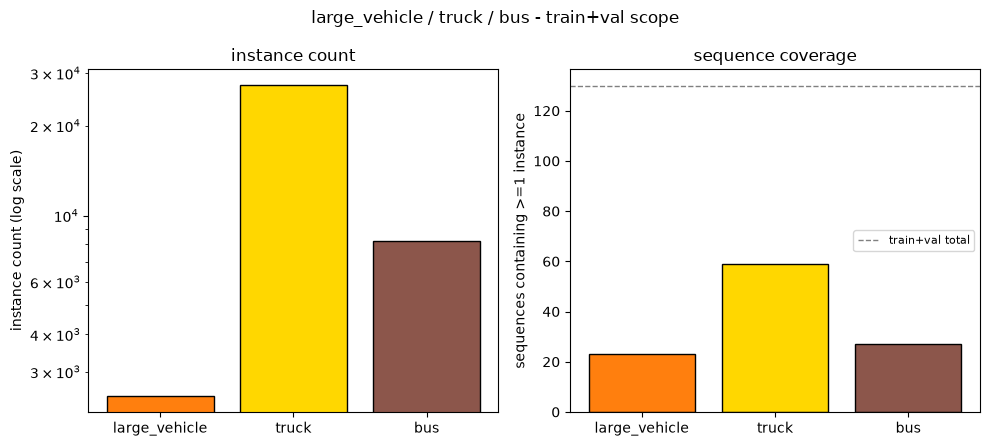

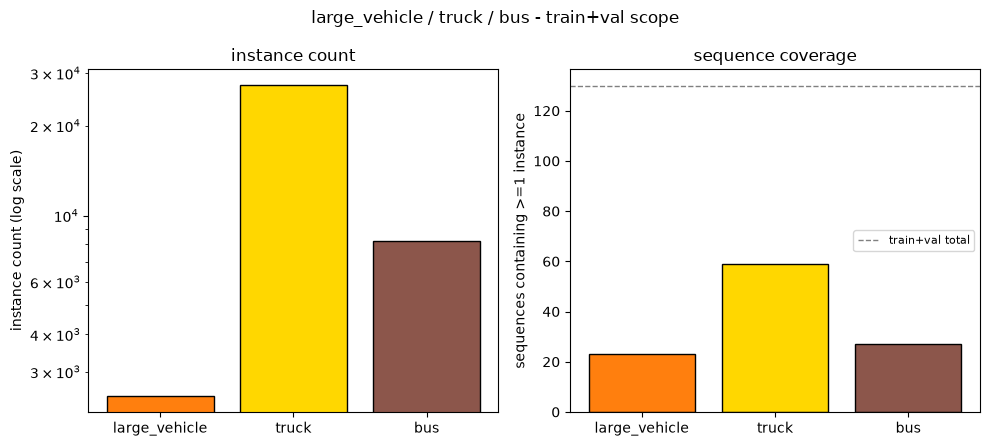

In [6]:
summary, fig = plot_taxonomy_class_balance(df)
fig

In [7]:
cv_results = run_separability_probe_cv(df)

38105 instances across 68 sequences (train+val only)


fold 1/5 done


fold 2/5 done


fold 3/5 done


fold 4/5 done


fold 5/5 done

=== logistic_regression (mean +/- std over 5 folds) ===
               auc_mean  auc_std
large_vehicle     0.779    0.041
truck             0.677    0.065
bus               0.756    0.070
               precision_mean  precision_std
large_vehicle           0.143          0.039
truck                   0.840          0.038
bus                     0.422          0.047
               recall_mean  recall_std
large_vehicle        0.683       0.140
truck                0.404       0.055
bus                  0.665       0.117
               f1_mean  f1_std
large_vehicle    0.233   0.052
truck            0.544   0.055
bus              0.513   0.063

=== random_forest (mean +/- std over 5 folds) ===
               auc_mean  auc_std
large_vehicle     0.791    0.084
truck             0.775    0.053
bus               0.818    0.068
               precision_mean  precision_std
large_vehicle           0.239          0.047
truck                   0.827          0.032
bus                

per-fold test-set instance counts:
      large_vehicle  truck   bus
fold                            
1               492   5402  1645
2               420   5512  1646
3               404   5557  1599
4               399   5529  1611
5               764   5382  1743
Saved /home/bruno/radar_machine_learning_ws/results/taxonomy/taxonomy_cv_fold_counts.png


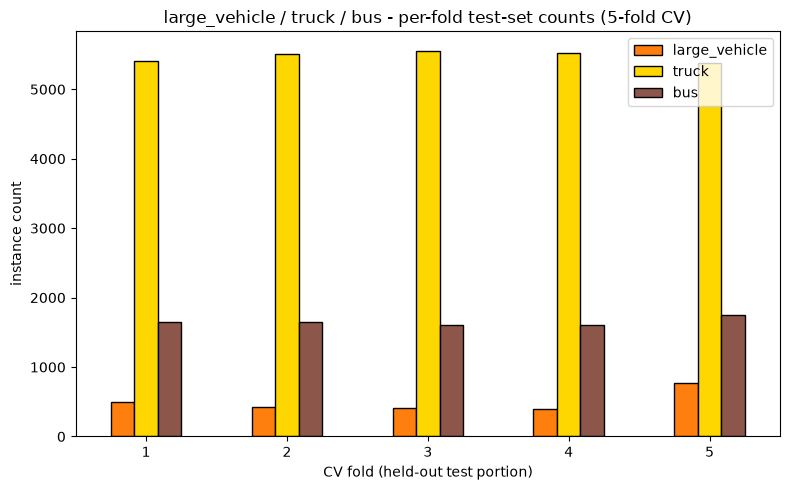

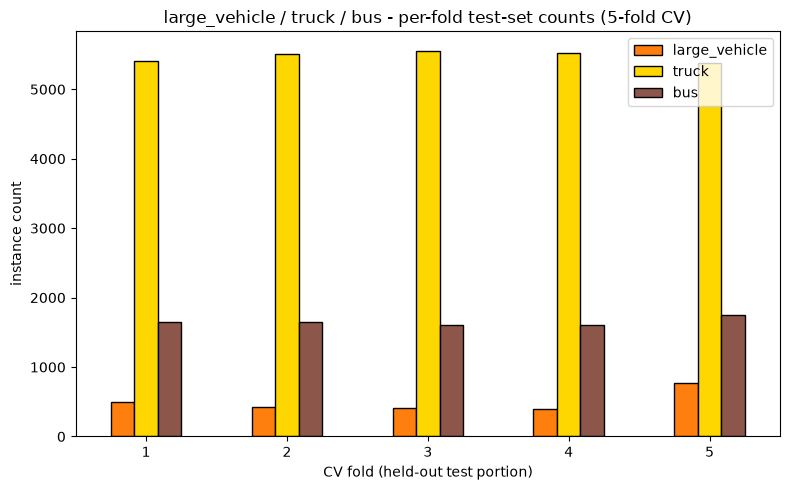

In [8]:
fold_summary, fold_fig = plot_cv_fold_class_counts(df)
fold_fig

**Findings (5-fold CV, train+val only, mean ± std):**

| class | LR AUC | LR F1 | RF AUC | RF F1 |
| --- | --- | --- | --- | --- |
| large_vehicle | 0.779 ± 0.041 | 0.233 ± 0.052 | 0.791 ± 0.084 | 0.244 ± 0.069 |
| truck | 0.677 ± 0.065 | 0.544 ± 0.055 | 0.775 ± 0.053 | 0.784 ± 0.070 |
| bus | 0.756 ± 0.070 | 0.513 ± 0.063 | 0.818 ± 0.068 | 0.554 ± 0.105 |

`large_vehicle` shows moderate AUC but poor practical performance: RF precision, recall, and F1 are all low, indicating substantial false positives and missed instances. Its high fold-to-fold variance is explained by limited sequence coverage rather than an inherently unstable radar signature.

`truck` is stable and performs well, while `bus` shows moderate performance. These results reinforce the decision to merge `large_vehicle` into `truck` while retaining `bus` as a separate class.